     y        x1        x2        x3        x4        x5        x6        x7  \
0  1.0  82.45990  82.53813  82.66825  82.84017  83.03401  83.22367  83.38251   
1  1.0  86.58631  86.49413  86.50027  86.60710  86.79449  87.02369  87.24665   
2  1.0  78.09365  78.18803  78.41095  78.75494  79.17267  79.58855  79.92040   
3  0.9  86.45770  86.61618  86.81481  87.06067  87.34476  87.64118  87.91244   
4  0.9  89.66774  89.46890  89.39058  89.46322  89.68008  89.99984  90.36047   

         x8        x9  ...     x7459     x7460     x7461     x7462     x7463  \
0  83.48845  83.52947  ...  78.01244  78.00971  78.01011  78.01308  78.01793   
1  87.41777  87.50520  ...  86.04174  86.04686  86.05158  86.05484  86.05661   
2  80.10236  80.10202  ...  78.83421  78.83932  78.84752  78.85775  78.86944   
3  88.11884  88.22964  ...  85.53087  85.54413  85.56237  85.58130  85.59742   
4  90.69912  90.96994  ...  92.99590  92.99141  92.98963  92.98827  92.98659   

      x7464     x7465     x7466     x7

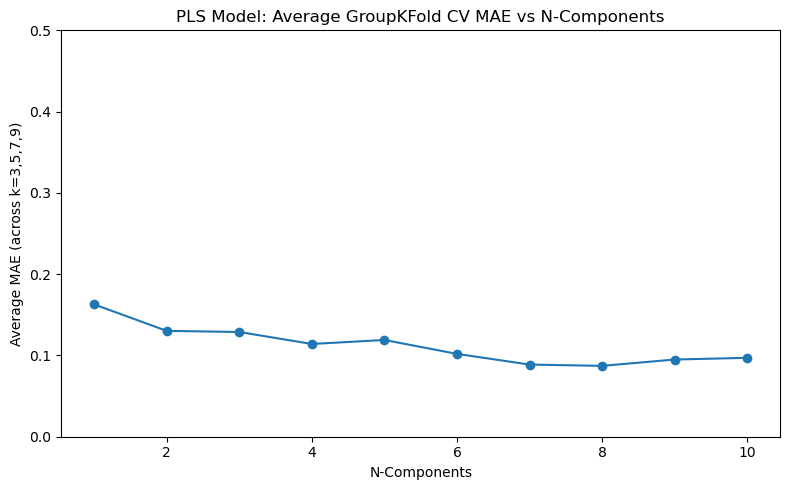

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.cross_decomposition import PLSRegression

root_directory = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2026_005/'

files = [file for file in os.listdir(root_directory) if file.lower().endswith('.csv')]
files.sort()

files = files[:33]

y_values = [1, 1, 1, 0.9, 0.9, 0.9, 0.8, 0.8, 0.8,
           0.7, 0.7, 0.7, 0.6, 0.6, 0.6, 0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 
            0.3, 0.3, 0.3, 0.2, 0.2, 0.2, 0.1, 0.1, 0.1, 0,0,0]
#y_values = [ 0,0,0, 0.1, 0.1, 0.1, 0.2, 0.2, 0.2,0.3, 0.3, 0.3, 0.4, 0.4, 0.4, 0.5, 0.5, 0.5,
#            0.6, 0.6, 0.6,  0.7, 0.7, 0.7, 0.8, 0.8, 0.8,0.9, 0.9, 0.9, 1,1,1]

if len(files) != len(y_values):
    raise ValueError("Number of Y values does not match number of files!")

rows = []

for file, y_value in zip(files, y_values):
    file_path = os.path.join(root_directory, file)
    data = pd.read_csv(file_path, header=None, skiprows=1)
    x_column = data.iloc[:, 1].values
    row = np.insert(x_column, 0, y_value)
    rows.append(row)

min_len = min(len(r) for r in rows)
trimmed_rows = [r[:min_len] for r in rows]

columns = ['y'] + [f'x{i+1}' for i in range(min_len - 1)]
final_df = pd.DataFrame(trimmed_rows, columns=columns)

print(final_df.head())
y = final_df.iloc[:, 0]
X = final_df.iloc[:, 1:]
print(X.head())
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)
print(y_train)

from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error 
from sklearn.model_selection import GroupKFold
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

groups = [i // 3 for i in range(len(files))] 
max_components = 10

final_scores = [] 

for n_comp in range(1, max_components + 1):
    mae_for_k = [] 
    
    for k in [3, 5, 7, 9]:
        gkf = GroupKFold(n_splits=k)
        fold_maes = []
        
        for train_index, val_index in gkf.split(X, y, groups):
            X_train, X_val = X.iloc[train_index], X.iloc[val_index]
            y_train, y_val = y.iloc[train_index], y.iloc[val_index]
            
            pls = PLSRegression(n_components=n_comp)
            pls.fit(X_train, y_train)
            y_pred = pls.predict(X_val)
            mae = mean_absolute_error(y_val, y_pred)
            fold_maes.append(mae)
        
        mean_mae_k = np.mean(fold_maes)
        print(f"n_components={n_comp}, k={k}, Mean MAE: {mean_mae_k:.4f}")
        mae_for_k.append(mean_mae_k)
    
    overall_avg_mae = np.mean(mae_for_k)
    print(f"n_components={n_comp}, Overall Avg MAE across k=3,5,7,9: {overall_avg_mae:.4f}")
    final_scores.append((n_comp, overall_avg_mae))
final_df = pd.DataFrame(final_scores, columns=['n_components', 'avg_mae'])

plt.figure(figsize=(8,5))
plt.plot(final_df['n_components'], final_df['avg_mae'], marker='o')
plt.ylim(0, 0.5)
plt.xlabel('N-Components')
plt.ylabel('Average MAE (across k=3,5,7,9)')
plt.title('PLS Model: Average GroupKFold CV MAE vs N-Components')
plt.tight_layout()
plt.show()

Found 33 calibration files
Loaded 33 spectra with 7468 features
Loaded 4 solvent spectra
Augmented dataset size: 561 samples
n_components=1, k=3, MAE=0.1596
n_components=1, k=5, MAE=0.1663
n_components=1, k=7, MAE=0.1760
n_components=1, k=9, MAE=0.1727
n_components=1, AVG MAE: 0.1686

n_components=2, k=3, MAE=0.1172
n_components=2, k=5, MAE=0.1222
n_components=2, k=7, MAE=0.1273
n_components=2, k=9, MAE=0.1210
n_components=2, AVG MAE: 0.1220

n_components=3, k=3, MAE=0.1104
n_components=3, k=5, MAE=0.1190
n_components=3, k=7, MAE=0.1212
n_components=3, k=9, MAE=0.1155
n_components=3, AVG MAE: 0.1165

n_components=4, k=3, MAE=0.1089
n_components=4, k=5, MAE=0.1112
n_components=4, k=7, MAE=0.1140
n_components=4, k=9, MAE=0.1117
n_components=4, AVG MAE: 0.1115

n_components=5, k=3, MAE=0.1106
n_components=5, k=5, MAE=0.1000
n_components=5, k=7, MAE=0.1054
n_components=5, k=9, MAE=0.1033
n_components=5, AVG MAE: 0.1048

n_components=6, k=3, MAE=0.1048
n_components=6, k=5, MAE=0.0900
n_comp

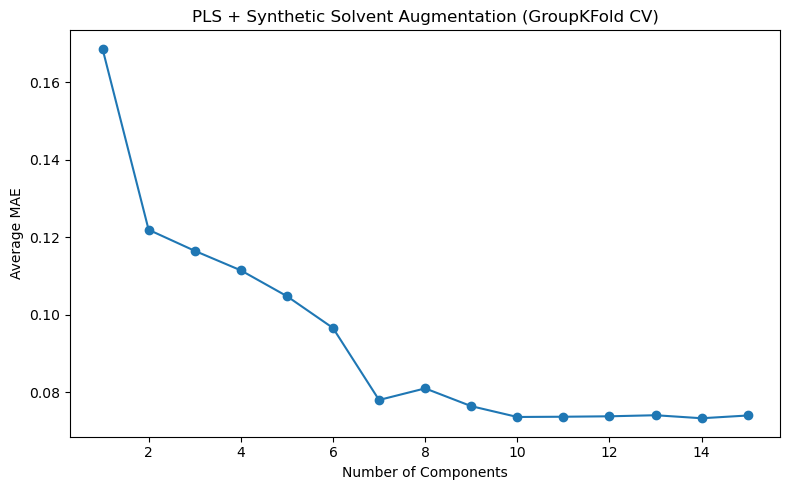

In [6]:
import os
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GroupKFold
import matplotlib.pyplot as plt

# PATHS (FIX THESE IF NEEDED)
root_calib = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2026_005/' 
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'

# CHECK PATHS
if not os.path.exists(root_calib):
    raise ValueError(f"Calibration folder not found: {root_calib}")

if not os.path.exists(solvent_dir):
    raise ValueError(f"Solvent folder not found: {solvent_dir}")

# LOAD FILES
calib_files = sorted([f for f in os.listdir(root_calib) if f.lower().endswith('.csv')])

if len(calib_files) == 0:
    raise ValueError("No CSV files found in calibration directory!")

calib_files = calib_files[:33]

print(f"Found {len(calib_files)} calibration files")

y_values = [1, 1, 1, 0.9, 0.9, 0.9, 0.8, 0.8, 0.8,
           0.7, 0.7, 0.7, 0.6, 0.6, 0.6, 0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 
            0.3, 0.3, 0.3, 0.2, 0.2, 0.2, 0.1, 0.1, 0.1, 0,0,0]

if len(calib_files) != len(y_values):
    raise ValueError("Mismatch between files and y_values!")

# LOAD SPECTRA
def load_spectrum(path):
    data = pd.read_csv(path, header=None, skiprows=1)
    return data.iloc[:, 1].values

rows = []

for file, y_val in zip(calib_files, y_values):
    path = os.path.join(root_calib, file)
    
    try:
        spec = load_spectrum(path)
        if len(spec) == 0:
            print(f"Skipping empty file: {file}")
            continue
        
        row = np.insert(spec, 0, y_val)
        rows.append(row)
        
    except Exception as e:
        print(f"Error loading {file}: {e}")


if len(rows) == 0:
    raise ValueError("No valid spectra loaded. Check your CSV format or paths.")

# ALIGN LENGTHS
min_len = min(len(r) for r in rows)
rows = [r[:min_len] for r in rows]

columns = ['y'] + [f'x{i}' for i in range(min_len-1)]
df = pd.DataFrame(rows, columns=columns)

y_calib = df['y'].values
X_calib = df.drop('y', axis=1).values

n_samples, n_features = X_calib.shape
print(f"Loaded {n_samples} spectra with {n_features} features")

# LOAD SOLVENTS
solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

solvents = {}

for file in solvent_files:
    path = os.path.join(solvent_dir, file)
    
    if not os.path.exists(path):
        print(f"WARNING: Missing solvent file: {file}")
        continue
    
    spec = load_spectrum(path)
    
    if len(spec) != n_features:
        spec = np.interp(np.linspace(0,1,n_features),
                         np.linspace(0,1,len(spec)), spec)
    
    solvents[file] = spec

if len(solvents) == 0:
    raise ValueError("No solvent spectra loaded!")

print(f"Loaded {len(solvents)} solvent spectra")


# SYNTHETIC AUGMENTATION
alphas = np.arange(0.1, 0.5, 0.1)

X_all = [X_calib]
y_all = [y_calib]
groups_all = [np.arange(len(y_calib))]

def synthesize(x, solvent, alpha):
    return x + alpha * solvent 

for solvent in solvents.values():
    for alpha in alphas:
        X_syn = np.array([synthesize(x, solvent, alpha) for x in X_calib])
        
        X_all.append(X_syn)
        y_all.append(y_calib)
        groups_all.append(np.arange(len(y_calib)))  # preserve grouping

X_all = np.vstack(X_all)
y_all = np.concatenate(y_all)
groups = np.concatenate(groups_all)

print(f"Augmented dataset size: {len(X_all)} samples")


# GROUP K-FOLD CV
max_components = 15
k_values = [3, 5, 7, 9]

results = []

for n_comp in range(1, max_components + 1):
    mae_across_k = []
    
    for k in k_values:
        gkf = GroupKFold(n_splits=k)
        fold_maes = []
        
        for train_idx, val_idx in gkf.split(X_all, y_all, groups):
            X_train, X_val = X_all[train_idx], X_all[val_idx]
            y_train, y_val = y_all[train_idx], y_all[val_idx]
            
            pls = PLSRegression(n_components=n_comp)
            pls.fit(X_train, y_train)
            
            y_pred = pls.predict(X_val)
            mae = mean_absolute_error(y_val, y_pred)
            fold_maes.append(mae)
        
        mean_mae_k = np.mean(fold_maes)
        print(f"n_components={n_comp}, k={k}, MAE={mean_mae_k:.4f}")
        mae_across_k.append(mean_mae_k)
    
    avg_mae = np.mean(mae_across_k)
    print(f"n_components={n_comp}, AVG MAE: {avg_mae:.4f}\n")
    
    results.append((n_comp, avg_mae))

# PLOTs
results_df = pd.DataFrame(results, columns=['n_components', 'avg_mae'])

plt.figure(figsize=(8,5))
plt.plot(results_df['n_components'], results_df['avg_mae'], marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Average MAE')
plt.title('PLS + Synthetic Solvent Augmentation (GroupKFold CV)')
plt.tight_layout()
plt.show()